                                                Employee Attrition Prediction

This project aims to predict employee attrition using machine learning techniques. This dataset contains employee-related information such as age, job role, salary, overtime status, and work experience. The objective is to identify patterns associated with employee turnover and build predictive models to classify whetheran employee is likely to leave the company.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (accuracy_score,confusion_matrix,classification_report,roc_curve,roc_auc_score)

In [6]:
df=pd.read_csv("employee_attrition.csv")

In [7]:
df.shape

(1470, 35)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [9]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [10]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [11]:
df.tail()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8
1469,34,No,Travel_Rarely,628,Research & Development,8,3,Medical,1,2068,...,1,80,0,6,3,4,4,3,1,2


In [12]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [13]:
df.duplicated().sum()

np.int64(0)

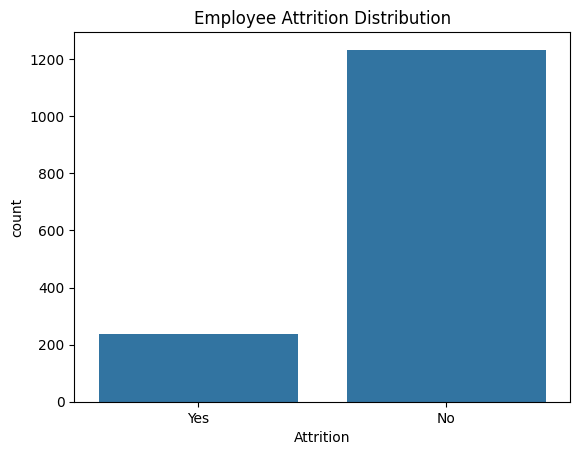

In [14]:
# ATTRITION DISTRIBUTION 

sns.countplot(x='Attrition',data=df)
plt.title('Employee Attrition Distribution')
plt.show()

# Insight

The majority of employees remained with the company, while only a small proportion left. This indicates that employee attrition is relatively low, with most employees choosing to stay in the organization.

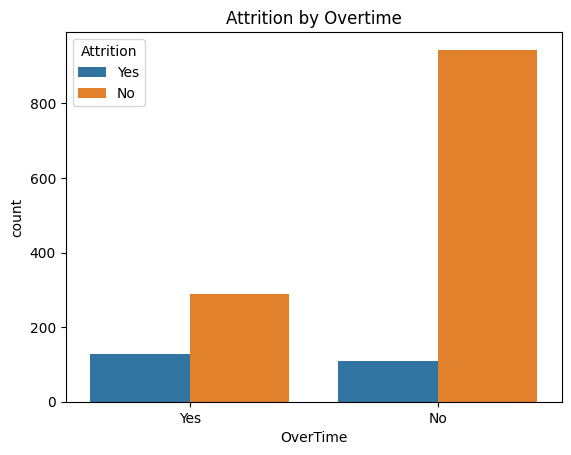

In [15]:
# ATTRITION VS OVERTIME

sns.countplot(x='OverTime',hue='Attrition',data=df)
plt.title("Attrition by Overtime")
plt.show()

## Insight

Employees who work overtime show a noticeably higher proportion of attrition compared to employees who do not work overtime. This suggests that overtime may be an important factor influencing employee turnover.

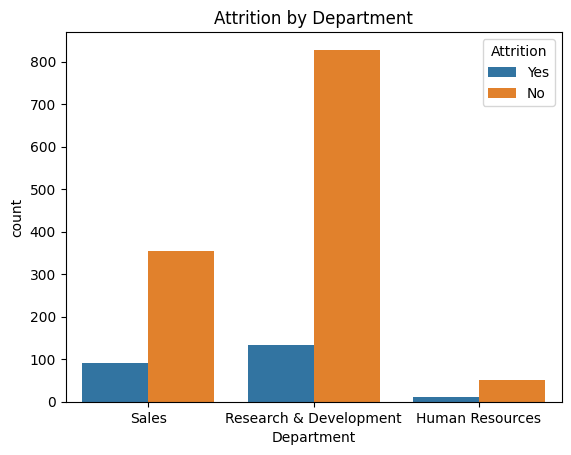

In [16]:
# ATTRITION VS DEPARTMENT

sns.countplot(x="Department",hue="Attrition",data=df)
plt.title("Attrition by Department")
plt.show()

## Insight

Research & Development recorded the highest number of attrition cases, followed by Sales, while Human Resources experienced the lowest attrition. This indicates that employee turnover varies across departments.

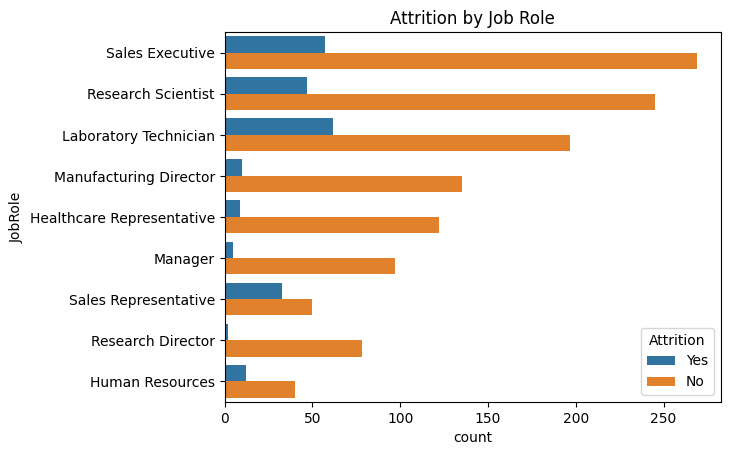

In [17]:
# ATTRITION VS JOB ROLE

sns.countplot(y="JobRole",hue="Attrition",data=df)
plt.title("Attrition by Job Role")
plt.show()

# Insight
Sales Executives, Laboratory Technicians, and Research Scientists show the highest attrition levels among all job roles. This suggests that employees
in these roles may be more likely to leave the organization.

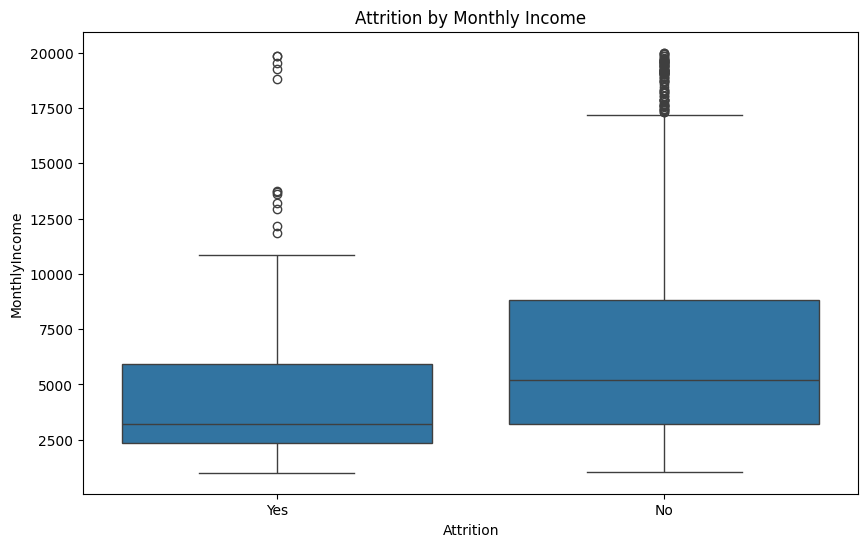

In [18]:
# ATTRITION VS MONTHLY INCOME
plt.figure(figsize=(10,6))
sns.boxplot(x="Attrition",y="MonthlyIncome",data=df)
plt.title("Attrition by Monthly Income")
plt.show()


### Insight

Employees who remained with the company generally have higher monthly incomes compared to those who left. This suggests that income level may play a role in employee retention.

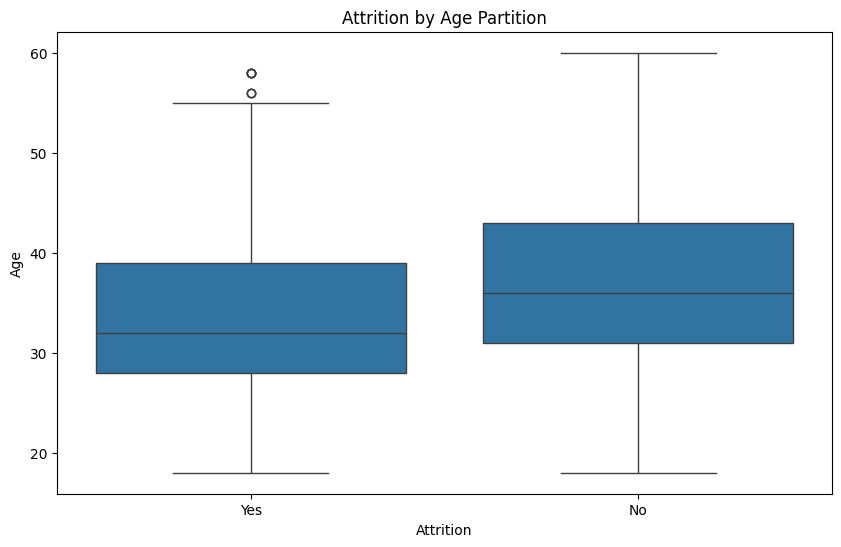

In [19]:
# ATTRITION VS AGE

plt.figure(figsize=(10,6))
sns.boxplot(x="Attrition",y="Age",data=df)
plt.title("Attrition by Age Partition")
plt.show()



## Insight

This visualization compares the age distribution of employees who stayed with the company and those who left. Understanding age-related patterns can help identify workforce groups that may be more prone to attrition.

In [20]:
df.select_dtypes(include='object').columns

Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'Over18', 'OverTime'],
      dtype='object')

In [21]:
df['Attrition'] = df['Attrition'].map({
    'Yes': 1,
    'No': 0
})

In [22]:
df['Attrition'].head()

0    1
1    0
2    1
3    0
4    0
Name: Attrition, dtype: int64

In [23]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for column in df.select_dtypes(include='object').columns:
    df[column] = le.fit_transform(df[column])

In [24]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,2,1102,2,1,2,1,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,0,1,279,1,8,1,1,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,1,2,1373,1,2,2,4,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,0,1,1392,1,3,4,1,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,0,2,591,1,2,1,3,1,7,...,4,80,1,6,3,3,2,2,2,2


In [25]:
X = df.drop('Attrition', axis=1)

y = df['Attrition']

In [24]:
print(X.shape)
print(y.shape)

(1470, 34)
(1470,)


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [26]:
print(X_train.shape)
print(X_test.shape)

(1176, 34)
(294, 34)


## Data Preparation Summary

In this phase, the dataset was prepared for machine learning model development. The target variable, Attrition, was converted into numerical form, and all remaining categorical features were encoded so that they could be processed by machine learning algorithms. The dataset was then separated into input features (X) and the target variable (y). Finally, the data was split into training and testing sets, with 80% used for training and 20% reserved for evaluating model performance. These preprocessing steps ensure that the data is ready for building and testing predictive models.

In [27]:
# DECISION TREEE CLASSIFIER

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(
    X_train,
    y_train
)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [29]:
y_pred_dt = dt_model.predict(X_test)

In [30]:
y_pred_dt[:10]

array([0, 0, 1, 0, 0, 1, 1, 0, 0, 0])

## Decision Tree Classifier

A Decision Tree Classifier was trained using the prepared dataset to predict employee attrition. The model learns decision rules from employee characteristics and uses them to classify whether an employee is likely to stay with the company or leave.

In [33]:
# RANDOM FOREST CLASSIFIER

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [34]:
y_pred_rf = rf_model.predict(
    X_test
)

In [35]:
y_pred_rf[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

## Random Forest Classifier

A Random Forest Classifier was trained to improve prediction performance by combining multiple decision trees. By aggregating the predictions of several trees, the model aims to produce more reliable and accurate classifications.

## Model Training Summary

In this phase, two machine learning models were trained using the employee attrition dataset. A Decision Tree Classifier and a Random Forest Classifier were developed to predict employee attrition based on employee-related features. Predictions were generated using both models and will be evaluated in the next phase to determine their effectiveness and overall performance.

In [1]:
dt_accuracy = accuracy_score(
    y_test,
    y_pred_dt
)

print("Decision Tree Accuracy:", dt_accuracy)

NameError: name 'accuracy_score' is not defined

### Insight

The Decision Tree model achieved an accuracy of 76.53%. This indicates that the model was able to correctly classify a majority of employee records, although some prediction errors were still present.

In [41]:
rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.8673469387755102


### Insight

The Random Forest model achieved an accuracy of 86.73%, outperforming the Decision Tree model. This suggests that combining multiple decision trees improved prediction accuracy and model reliability.

In [42]:
cm_dt = confusion_matrix(
    y_test,
    y_pred_dt
)

print(cm_dt)

[[218  37]
 [ 32   7]]


### Insight

The Decision Tree model correctly classified most employees who remained with the company. However, it struggled to identify employees who left, resulting in several misclassifications. This indicates that while the model performs reasonably well overall, its ability to detect attrition is limited.

In [43]:
cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

print(cm_rf)

[[251   4]
 [ 35   4]]


### Insight

The Random Forest model achieved a higher number of correct classifications compared to the Decision Tree model. It was particularly effective at identifying employees who stayed with the company, although it still faced challenges in accurately detecting employees who left.

In [44]:
print(classification_report(
    y_test,
    y_pred_dt
))

              precision    recall  f1-score   support

           0       0.87      0.85      0.86       255
           1       0.16      0.18      0.17        39

    accuracy                           0.77       294
   macro avg       0.52      0.52      0.52       294
weighted avg       0.78      0.77      0.77       294



### Insight

The Decision Tree model achieved moderate performance in predicting employee attrition. While it performed well in identifying employees who stayed with the company, its ability to correctly detect employees who left was limited. This indicates that further improvements may be needed to better capture attrition patterns.

In [45]:
print(classification_report(
    y_test,
    y_pred_rf
))

              precision    recall  f1-score   support

           0       0.88      0.98      0.93       255
           1       0.50      0.10      0.17        39

    accuracy                           0.87       294
   macro avg       0.69      0.54      0.55       294
weighted avg       0.83      0.87      0.83       294



### Insight

The Random Forest model achieved higher overall accuracy and stronger performance in identifying employees who remained with the company. However, the model was less effective at detecting employees who left, suggesting that the class imbalance in the dataset may have influenced its predictions.

In [46]:
comparison = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest'],
    'Accuracy': [dt_accuracy, rf_accuracy]
})

comparison

,Model,Accuracy
0,Decision Tree,0.765306
1,Random Forest,0.867347


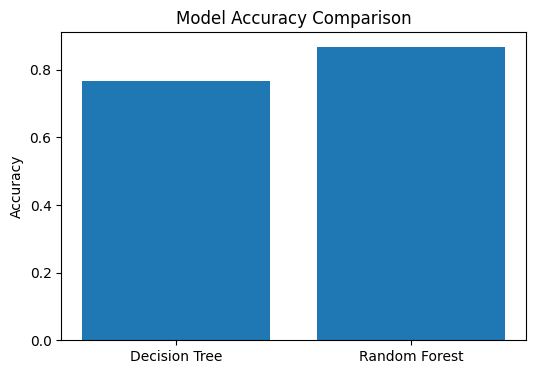

In [47]:
plt.figure(figsize=(6,4))

plt.bar(
    comparison['Model'],
    comparison['Accuracy']
)

plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')

plt.show()

## Model Comparison Summary

The performance of both machine learning models was compared using accuracy scores and evaluation metrics. The Random Forest model consistently outperformed the Decision Tree model and demonstrated better predictive capability. As a result, Random Forest was selected as the final model for employee attrition prediction.

# Conclusion

In this project, employee attrition data was analyzed to understand the factors that may influence employees leaving an organization. The dataset was explored, visualized, and prepared for machine learning through preprocessing and feature encoding techniques.

The analysis showed that factors such as overtime, job role, department, monthly income, and age may have an impact on employee attrition. These insights provided a better understanding of employee behavior and workforce trends.

Two machine learning models were developed and evaluated. The Decision Tree model achieved an accuracy of 76.53%, while the Random Forest model achieved an accuracy of 86.73%. Based on the evaluation metrics, Random Forest performed better and was selected as the final model.

This project highlights how machine learning can be applied to real-world HR data to support data-driven decision-making. The findings can help organizations identify potential attrition risks and take steps to improve employee retention.